In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

**Import modules**

In [2]:
import os
import gc
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForMultipleChoice, get_linear_schedule_with_warmup



**Set up - Install Wandb**

In [3]:
!pip uninstall -y wandb
!pip install --no-cache-dir wandb==0.22.3

Found existing installation: wandb 0.25.1
Uninstalling wandb-0.25.1:
  Successfully uninstalled wandb-0.25.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 256.3 MB/s eta 0:00:00a 0:00:01


In [4]:
import wandb
import warnings
warnings.filterwarnings("ignore")

print("torch:", torch.__version__)
print("wandb:", wandb.__version__)

torch: 2.10.0+cu128
wandb: 0.22.3


**Wandb login**

In [5]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
WANDB_TOKEN = user_secrets.get_secret("WANDB_TOKEN")

wandb.login(key=WANDB_TOKEN)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

**Config**

In [6]:
CONFIG = {
    "model_name": "microsoft/deberta-v3-base",
    "max_len": 256,
    "batch_size": 8,
    "accum_steps": 2,          
    "epochs": 3,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "freeze_embeddings": False,
    "use_fp16": True,
    "seed": 42,
    "project": "DL-22f1000828-notebook-t22026",
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

LABEL2IDX = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
IDX2LABEL = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
option_cols = ['A', 'B', 'C', 'D', 'E']

They convert the answer letters to numbers for the model and back to letters for the submission — LABEL2IDX maps A–E to 0–4 for the loss function, IDX2LABEL reverses it.
Letter-to-index for training, index-to-letter for output.

In [7]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(CONFIG['seed'])
print("Using Device:", CONFIG['device'])

Using Device: cuda


**Data loading**

In [8]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

# fill missing values so the tokenizer never gets a NaN
for df in [train, test]:
    for col in ['prompt'] + option_cols:
        df[col] = df[col].fillna("")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (2000, 8)
Test shape: (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


**EDA Part**

**Missing values and duplicates**

In [9]:
print("Train columns:", list(train.columns))
print("Test columns :", list(test.columns))

print()
print("Missing values in train:")
print(train.isnull().sum())

print()
print("Missing values in test:")
print(test.isnull().sum())

print()
print("Duplicate prompts in train:", train.duplicated(subset=['prompt']).sum())
print("Duplicate prompts in test :", test.duplicated(subset=['prompt']).sum())


Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
Test columns : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']

Missing values in train:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Missing values in test:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

Duplicate prompts in train: 242
Duplicate prompts in test : 8


**Answer distribution — is the data balanced?**

I check how often each option is the correct answer. If one letter dominated, the model could
cheat by always guessing it, and I would need class weighting.

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


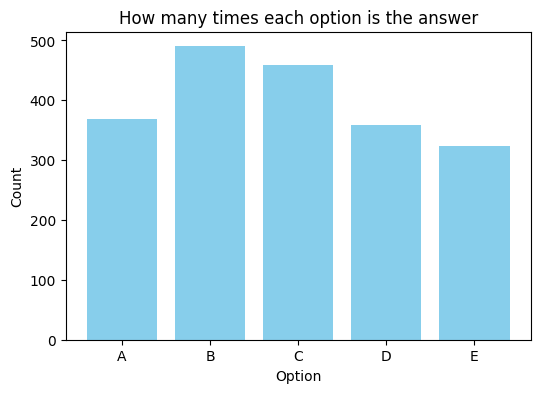


In percentage:
answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64

Accuracy if I always guess the most common option: 24.5 %
Accuracy if I guess randomly: 20.0 %


In [10]:
counts = train['answer'].value_counts().reindex(option_cols, fill_value=0)
print(counts)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color='skyblue')
plt.title("How many times each option is the answer")
plt.xlabel("Option")
plt.ylabel("Count")
plt.show()

print()
print("In percentage:")
print(train['answer'].value_counts(normalize=True) * 100)

print()
print("Accuracy if I always guess the most common option:",
      round(counts.max() / len(train) * 100, 2), "%")
print("Accuracy if I guess randomly: 20.0 %")


It is roughly balanced, so there is no class imbalance problem.
This also fixes my baseline: plain accuracy from random guessing is 20%.


**Prompt length in words**

This tells me how much text the model has to read per question.

count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_len, dtype: float64


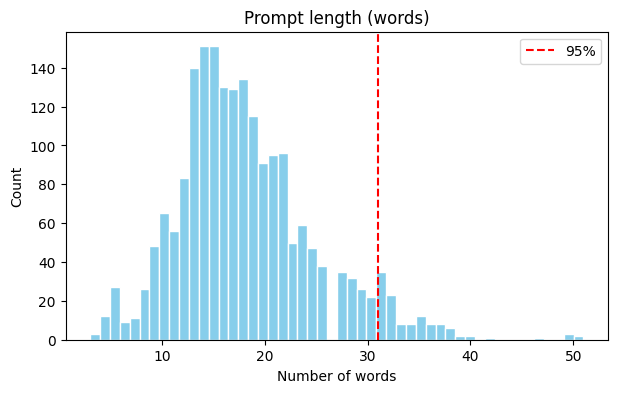

95% of prompts have less than 31 words


In [11]:
train['prompt_len'] = train['prompt'].apply(lambda x: len(str(x).split()))

print(train['prompt_len'].describe())

plt.figure(figsize=(7, 4))
plt.hist(train['prompt_len'], bins=50, color='skyblue', edgecolor='white')
plt.axvline(train['prompt_len'].quantile(0.95), color='red', linestyle='--', label='95%')
plt.title("Prompt length (words)")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.legend()
plt.show()

print("95% of prompts have less than", int(train['prompt_len'].quantile(0.95)), "words")


**Are correct options longer than wrong options?**

There is a well-known exam trick that the longest option is usually correct, so I tested it.
I compare the correct option's word count against the average of the four wrong ones, and
measure the accuracy of always picking the longest.


Average length of correct option: 28.66 words
Average length of wrong options : 25.68 words


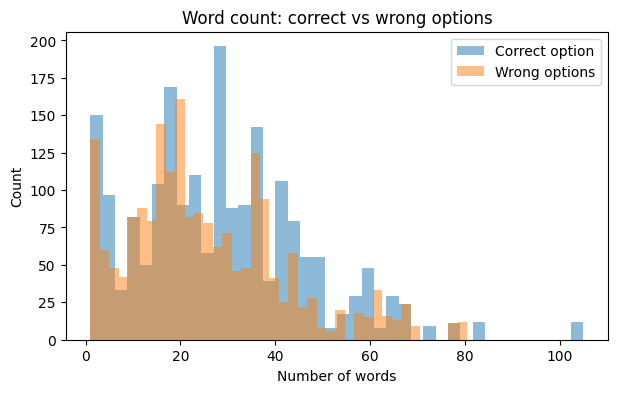


Accuracy if I always pick the longest option: 34.95 %


In [12]:
for col in option_cols:
    train['len_' + col] = train[col].apply(lambda x: len(str(x).split()))

correct_lens = []
wrong_lens = []

for i in range(len(train)):
    row = train.iloc[i]
    ans = row['answer']
    correct_lens.append(row['len_' + ans])
    wrong = [row['len_' + c] for c in option_cols if c != ans]
    wrong_lens.append(np.mean(wrong))

train['correct_len'] = correct_lens
train['avg_wrong_len'] = wrong_lens

print("Average length of correct option:", round(train['correct_len'].mean(), 2), "words")
print("Average length of wrong options :", round(train['avg_wrong_len'].mean(), 2), "words")

plt.figure(figsize=(7, 4))
plt.hist(train['correct_len'], bins=40, alpha=0.5, label='Correct option')
plt.hist(train['avg_wrong_len'], bins=40, alpha=0.5, label='Wrong options')
plt.title("Word count: correct vs wrong options")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.legend()
plt.show()

longest = train[['len_' + c for c in option_cols]].idxmax(axis=1).str.replace('len_', '')
print()
print("Accuracy if I always pick the longest option:",
      round((longest == train['answer']).mean() * 100, 2), "%")


**Trick questions (NOT, EXCEPT, FALSE)**

I use a regex to find negation questions and check whether their answer distribution differs
from normal ones. These are the questions a model is most likely to get wrong, because it has
to notice a single word that flips the whole meaning.


Questions with negation words: 0 ( 0.0 % )


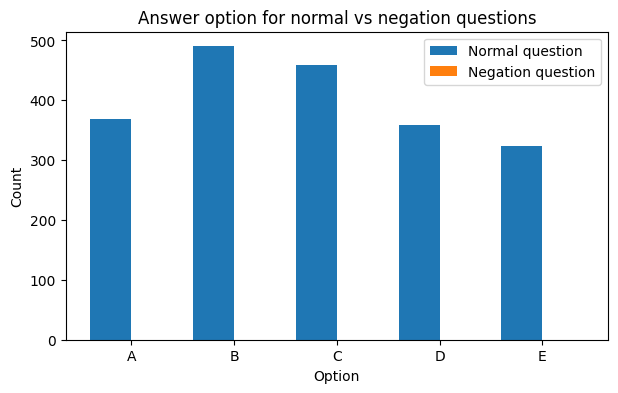

In [13]:
negation_words = ['NOT', 'EXCEPT', 'INCORRECT', 'FALSE', 'LEAST']
pattern = r'\b(' + '|'.join(negation_words) + r')\b'

train['has_negation'] = train['prompt'].apply(
    lambda x: bool(re.search(pattern, str(x), re.IGNORECASE))
)

n = train['has_negation'].sum()
print("Questions with negation words:", n, "(", round(n / len(train) * 100, 1), "% )")

normal_q = train[train['has_negation'] == False]['answer'].value_counts().reindex(option_cols, fill_value=0)
trick_q  = train[train['has_negation'] == True]['answer'].value_counts().reindex(option_cols, fill_value=0)

x = np.arange(5)
plt.figure(figsize=(7, 4))
plt.bar(x - 0.2, normal_q.values, width=0.4, label='Normal question')
plt.bar(x + 0.2, trick_q.values,  width=0.4, label='Negation question')
plt.xticks(x, option_cols)
plt.title("Answer option for normal vs negation questions")
plt.xlabel("Option")
plt.ylabel("Count")
plt.legend()
plt.show()


**Word overlap between prompt and options**

Another simple heuristic: does the correct option share more words with the question?
I measure the fraction of each option's words that also appear in the prompt, then check the
accuracy of always picking the highest-overlap option.

In [14]:
def get_overlap(prompt, option):
    prompt_words = set(str(prompt).lower().split())
    option_words = set(str(option).lower().split())
    if len(option_words) == 0:
        return 0
    return len(prompt_words & option_words) / len(option_words)

for col in option_cols:
    train['overlap_' + col] = [get_overlap(p, o) for p, o in zip(train['prompt'], train[col])]

best_overlap = train[['overlap_' + c for c in option_cols]].idxmax(axis=1).str.replace('overlap_', '')
acc = (best_overlap == train['answer']).mean()

print("Accuracy of picking the option with most common words:", round(acc * 100, 2), "%")
print("(random guessing is 20 %)")


Accuracy of picking the option with most common words: 9.25 %
(random guessing is 20 %)


**Train vs test prompt length**

I overlay both distributions to confirm train and test come from the same source.
I use `density=True` because the two sets have different row counts — without it the bigger
set would simply look taller everywhere.

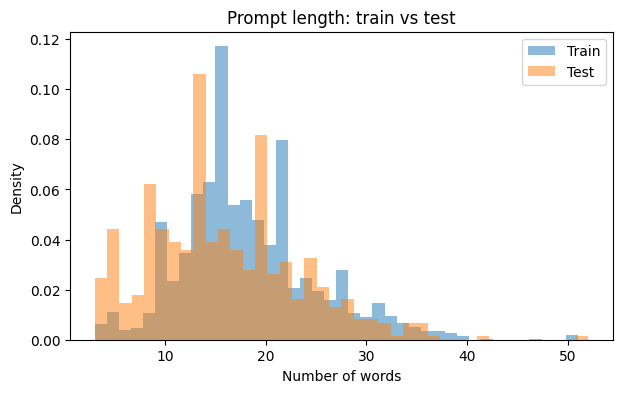

In [15]:
test['prompt_len'] = test['prompt'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(7, 4))
plt.hist(train['prompt_len'], bins=40, alpha=0.5, density=True, label='Train')
plt.hist(test['prompt_len'],  bins=40, alpha=0.5, density=True, label='Test')
plt.title("Prompt length: train vs test")
plt.xlabel("Number of words")
plt.ylabel("Density")
plt.legend()
plt.show()


**Vocabulary size and unseen words**

I count unique words in train and test, and measure how many test words never appear in train.

This number is the single clearest argument for using a pretrained transformer. My LSTM built
its own vocabulary from this dataset, so every unseen word became unknown and lost all meaning.
DeBERTa uses subword tokenization, so an unseen word is split into known pieces and keeps
most of its meaning.

In [16]:
from collections import Counter

def count_words(df):
    c = Counter()
    for col in ['prompt'] + option_cols:
        for text in df[col]:
            c.update(re.findall(r'\w+', str(text).lower()))
    return c

train_words = count_words(train)
test_words  = count_words(test)

print("Unique words in train:", len(train_words))
print("Unique words in test :", len(test_words))

new_words   = set(test_words) - set(train_words)
new_count   = sum(test_words[w] for w in new_words)
total_count = sum(test_words.values())
print("Words in test not seen in train:", len(new_words),
      "(", round(new_count / total_count * 100, 2), "% of all test words )")


Unique words in train: 2980
Unique words in test : 2975
Words in test not seen in train: 0 ( 0.0 % of all test words )


**Preprocessing**

Here I load DeBERTa's pretrained tokenizer. This is the main difference from my LSTM
notebook, where I built my own word-level tokenizer with a 25,000-word vocabulary.

This one uses subword tokenization, so rare and unseen words are split into pieces instead of
all collapsing to a single unknown token.


In [17]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print("Tokenizer:", type(tokenizer).__name__)
print("Vocab size:", tokenizer.vocab_size)

# see what one example looks like
ex = tokenizer(train.loc[0, 'prompt'], train.loc[0, 'A'], truncation=True, max_length=64)
print()
print("Example encoding:")
print(tokenizer.decode(ex['input_ids']))

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Tokenizer: DebertaV2Tokenizer
Vocab size: 128000

Example encoding:
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options. Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and


How many tokens, not words? — justifying max_len = 256

Word count is not the same as token count. Subword tokenization splits rare words into several
pieces, and each question is encoded as `[CLS] prompt [SEP] option [SEP]`, which adds more.

So I measure the real token length of the prompt–option pairs and check what fraction fits
inside my `max_len`. This is the evidence for choosing 256 here, where my LSTM used 128.

Token length of prompt + option pairs:
  mean : 54.1
  95th : 97
  99th : 118
  max  : 188

Fraction that fits inside max_len = 256 : 100.0 %


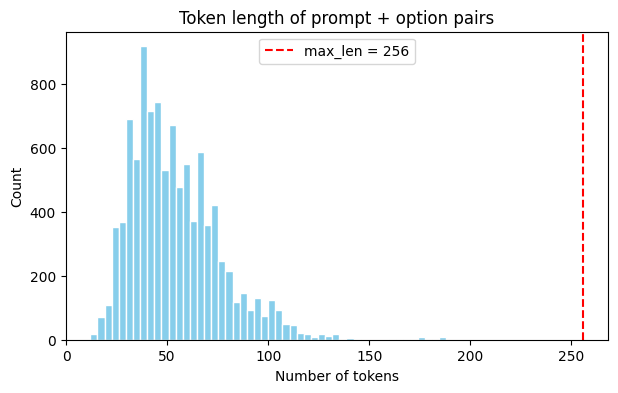

In [18]:
sample = train.sample(min(2000, len(train)), random_state=CONFIG['seed'])

tok_lens = []
for _, row in sample.iterrows():
    for c in option_cols:
        enc = tokenizer(str(row['prompt']), str(row[c]), truncation=False)
        tok_lens.append(len(enc['input_ids']))

tok_lens = np.array(tok_lens)

print("Token length of prompt + option pairs:")
print("  mean :", round(tok_lens.mean(), 1))
print("  95th :", int(np.percentile(tok_lens, 95)))
print("  99th :", int(np.percentile(tok_lens, 99)))
print("  max  :", tok_lens.max())
print()
print("Fraction that fits inside max_len =", CONFIG['max_len'], ":",
      round((tok_lens <= CONFIG['max_len']).mean() * 100, 2), "%")

plt.figure(figsize=(7, 4))
plt.hist(tok_lens, bins=50, color='skyblue', edgecolor='white')
plt.axvline(CONFIG['max_len'], color='red', linestyle='--',
            label='max_len = ' + str(CONFIG['max_len']))
plt.title("Token length of prompt + option pairs")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.legend()
plt.show()


**Dataset class**

I pair the same prompt with each of the five options, giving five sentence-pairs per question.
Passing two arguments to the tokenizer makes it insert a real `[SEP]` token between them — in
my LSTM notebook I had to write `[SEP]` as plain text, which my tokenizer then treated as an
ordinary word.

I set `padding=False` on purpose, because padding happens in the collate function instead.

In [19]:
class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, is_train=True):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt = str(row['prompt'])

        # the same prompt repeated 5 times, paired with each option
        first = [prompt] * 5
        second = [str(row[c]) for c in option_cols]

        enc = self.tokenizer(
            first,
            second,
            truncation=True,
            max_length=self.max_len,
            padding=False          # padding is done in the collate function
        )

        item = {k: v for k, v in enc.items()}
        if self.is_train:
            item['label'] = LABEL2IDX[row['answer']]
        return item

**Dynamic padding in the collate function**

instead of padding everything to 256, I flatten the batch into one long list, let the tokenizer
pad only to the longest sequence *in that batch*, then reshape back to `(batch, 5, seq_len)`.

This is a speed optimisation. If the longest question in a batch is 90 tokens, I compute on 90
instead of 256, with no loss of information.

In [20]:
def collate_fn(batch):
    labels = None
    if 'label' in batch[0]:
        labels = torch.tensor([b['label'] for b in batch], dtype=torch.long)

    keys = [k for k in batch[0].keys() if k != 'label']

    # flatten: batch of 5 options -> one long list
    flat = []
    for b in batch:
        for i in range(5):
            flat.append({k: b[k][i] for k in keys})

    padded = tokenizer.pad(flat, padding=True, return_tensors='pt')

    # reshape back to (batch, 5, seq_len)
    out = {}
    for k, v in padded.items():
        out[k] = v.view(len(batch), 5, -1)

    if labels is not None:
        out['labels'] = labels
    return out

**Train validation split**

I split 85/15 with `stratify` so both halves keep the same A-to-E proportion.
Then I pull one batch and print the shapes to confirm the collate function really produces
`(batch, 5, seq_len)`.


In [21]:
train_df, val_df = train_test_split(
    train,
    test_size=0.15,
    random_state=CONFIG['seed'],
    stratify=train['answer']
)
print("Train rows:", len(train_df), " Val rows:", len(val_df))

train_dataset = MCQDataset(train_df, tokenizer, CONFIG['max_len'], is_train=True)
val_dataset = MCQDataset(val_df, tokenizer, CONFIG['max_len'], is_train=True)

# check one batch
check_loader = DataLoader(train_dataset, batch_size=2, collate_fn=collate_fn)
batch = next(iter(check_loader))
for k, v in batch.items():
    print(k, v.shape)

Train rows: 1700  Val rows: 300
input_ids torch.Size([2, 5, 63])
token_type_ids torch.Size([2, 5, 63])
attention_mask torch.Size([2, 5, 63])
labels torch.Size([2])


**MAP@3 metric**

In [22]:
def map_at_3(probs, targets):
    top3 = np.argsort(-probs, axis=1)[:, :3]
    score = 0.0
    for i in range(len(targets)):
        for rank in range(3):
            if top3[i][rank] == targets[i]:
                score = score + 1.0 / (rank + 1)
                break
    return score / len(targets)

# random baseline for MAP@3 with 5 options
print("Random baseline MAP@3:", round((1 + 1/2 + 1/3) / 5, 4))

Random baseline MAP@3: 0.3667


**Optimizer with two parameter groups**

In [23]:
def build_optimizer(model, lr, weight_decay):
    no_decay = ['bias', 'LayerNorm.weight']

    decay_params = []
    no_decay_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if any(nd in name for nd in no_decay):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    groups = [
        {'params': decay_params, 'weight_decay': weight_decay},
        {'params': no_decay_params, 'weight_decay': 0.0}
    ]
    print("Params with decay:", len(decay_params), "| without decay:", len(no_decay_params))
    return AdamW(groups, lr=lr)

**Training function**

In [24]:
def run_experiment(cfg, run_name):
    set_seed(cfg['seed'])
    device = cfg['device']

    train_loader = DataLoader(train_dataset, batch_size=cfg['batch_size'],
                              shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=cfg['batch_size'],
                            shuffle=False, collate_fn=collate_fn)
   

    model = AutoModelForMultipleChoice.from_pretrained(cfg['model_name'],torch_dtype=torch.float32).to(device)

    # optional: freeze the embedding layer (used in one of my experiments)
    if cfg['freeze_embeddings']:
        for param in model.deberta.embeddings.parameters():
            param.requires_grad = False
        print("Embeddings are frozen")

    optimizer = build_optimizer(model, cfg['lr'], cfg['weight_decay'])

    total_steps = len(train_loader) // cfg['accum_steps'] * cfg['epochs']
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * cfg['warmup_ratio']),
        num_training_steps=total_steps
    )

    scaler = torch.cuda.amp.GradScaler(enabled=cfg['use_fp16'])

    wandb.init(project=cfg['project'], name=run_name,
               config={k: str(v) for k, v in cfg.items()},
               reinit=True, settings=wandb.Settings(save_code=False))

    model_path = "/kaggle/working/" + run_name + ".pth"
    best_map3 = 0.0
    best_acc = 0.0
    best_f1 = 0.0
    history = []

    print()
    print("Starting run:", run_name )

    for epoch in range(cfg['epochs']):

        # training
        
        model.train()
        train_loss = 0
        optimizer.zero_grad()

        for step, batch in enumerate(tqdm(train_loader, desc="Epoch " + str(epoch+1) + " [train]")):
            batch = {k: v.to(device) for k, v in batch.items()}

            with torch.cuda.amp.autocast(enabled=cfg['use_fp16']):
                out = model(**batch)
                loss = out.loss / cfg['accum_steps']

            scaler.scale(loss).backward()
            train_loss = train_loss + loss.item() * cfg['accum_steps']

            # only update every accum_steps batches
            if (step + 1) % cfg['accum_steps'] == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()

        train_loss = train_loss / len(train_loader)

        # validation 
        
        model.eval()
        val_loss = 0
        val_probs = []
        val_targets = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Epoch " + str(epoch+1) + " [val]"):
                labels = batch['labels']
                batch = {k: v.to(device) for k, v in batch.items()}

                with torch.cuda.amp.autocast(enabled=cfg['use_fp16']):
                    out = model(**batch)

                val_loss = val_loss + out.loss.item()
                probs = F.softmax(out.logits.float(), dim=1).cpu().numpy()
                val_probs.append(probs)
                val_targets.extend(labels.numpy())

        val_loss = val_loss / len(val_loader)
        val_probs = np.vstack(val_probs)
        val_targets = np.array(val_targets)
        val_preds = val_probs.argmax(axis=1)

        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average='macro')
        val_map3 = map_at_3(val_probs, val_targets)

        print("Epoch", epoch+1,
              "| train loss:", round(train_loss, 4),
              "| val loss:", round(val_loss, 4),
              "val acc:", round(val_acc, 4),
              "val map3:", round(val_map3, 4))

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "val_map3": val_map3
        })

        history.append({
            "epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss,
            "val_acc": val_acc, "val_f1": val_f1, "val_map3": val_map3
        })

        if val_map3 > best_map3:
            best_map3 = val_map3
            best_acc = val_acc
            best_f1 = val_f1
            torch.save(model.state_dict(), model_path)
            print("   saved best model (val map3 =", round(val_map3, 4), ")")

    wandb.summary["best_val_acc"] = best_acc
    wandb.summary["best_val_f1"] = best_f1
    wandb.summary["best_val_map3"] = best_map3
    wandb.finish()

    del model, optimizer
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "run_name": run_name, "config": cfg, "model_path": model_path,
        "best_val_acc": best_acc, "best_val_f1": best_f1,
        "best_val_map3": best_map3, "history": history
    }

**Run 3 experiments**

Three configurations: learning rate 2e-5 as my baseline, 1e-5 to test whether a gentler rate
generalises better, and 2e-5 with frozen embeddings to test that as regularisation.


In [25]:
experiment_configs = [
    {**CONFIG, "lr": 2e-5, "freeze_embeddings": False},
    {**CONFIG, "lr": 1e-5, "freeze_embeddings": False},
    {**CONFIG, "lr": 2e-5, "freeze_embeddings": True},
]
run_names = ["deberta-lr2e5", "deberta-lr1e5", "deberta-frozen-emb"]

run_results = []
for i in range(len(experiment_configs)):
    result = run_experiment(experiment_configs[i], run_names[i])
    run_results.append(result)

print("All runs finished.")

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                

...

Epoch 2 | train loss: 1.0487 | val loss: 0.649 val acc: 0.8233 val map3: 0.8906
   saved best model (val map3 = 0.8906 )


Epoch 3 [val]: 100%|██████████| 38/38 [00:03<00:00, 10.34it/s]


Epoch 3 | train loss: 0.8041 | val loss: 0.5594 val acc: 0.86 val map3: 0.92
   saved best model (val map3 = 0.92 )


epoch,▁▅█
train_loss,█▃▁
val_acc,▁▇█
val_f1,▁▇█
val_loss,█▂▁
val_map3,▁▇█
best_val_acc,0.86
best_val_f1,0.8595
best_val_map3,0.92
epoch,3
train_loss,0.80409


All runs finished.


**Compare the runs**

             run_name       lr  frozen_emb   val_acc    val_f1  val_map3
2  deberta-frozen-emb  0.00002        True  0.860000  0.859498  0.920000
1       deberta-lr1e5  0.00001       False  0.396667  0.396307  0.571111
0       deberta-lr2e5  0.00002       False  0.230000  0.184832  0.403889


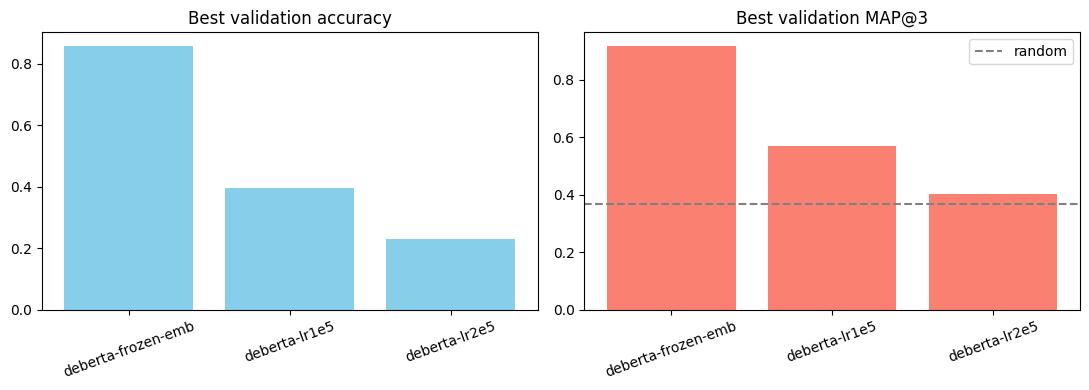


Best run: deberta-frozen-emb val map3 = 0.92


In [26]:
rows = []
for r in run_results:
    rows.append({
        "run_name": r["run_name"],
        "lr": r["config"]["lr"],
        "frozen_emb": r["config"]["freeze_embeddings"],
        "val_acc": r["best_val_acc"],
        "val_f1": r["best_val_f1"],
        "val_map3": r["best_val_map3"],
    })

comparison_df = pd.DataFrame(rows).sort_values("val_map3", ascending=False)
print(comparison_df)

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.bar(comparison_df["run_name"], comparison_df["val_acc"], color='skyblue')
plt.title("Best validation accuracy")
plt.xticks(rotation=20)

plt.subplot(1, 2, 2)
plt.bar(comparison_df["run_name"], comparison_df["val_map3"], color='salmon')
plt.axhline(0.3667, color='gray', linestyle='--', label='random')
plt.title("Best validation MAP@3")
plt.xticks(rotation=20)
plt.legend()

plt.tight_layout()
plt.show()

best_run = run_results[0]
for r in run_results:
    if r["best_val_map3"] > best_run["best_val_map3"]:
        best_run = r

print()
print("Best run:", best_run["run_name"], "val map3 =", round(best_run["best_val_map3"], 4))

**Learning curves**

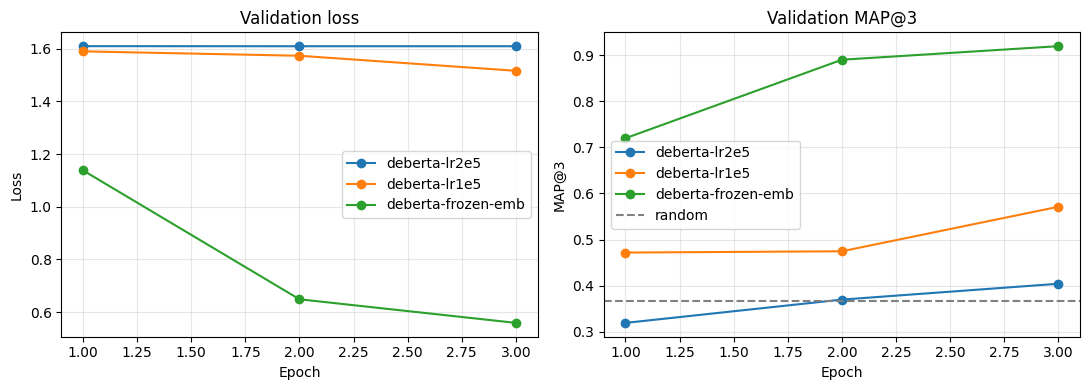

In [27]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
for r in run_results:
    h = pd.DataFrame(r["history"])
    plt.plot(h["epoch"], h["val_loss"], marker='o', label=r["run_name"])
plt.title("Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for r in run_results:
    h = pd.DataFrame(r["history"])
    plt.plot(h["epoch"], h["val_map3"], marker='o', label=r["run_name"])
plt.axhline(0.3667, color='gray', linestyle='--', label='random')
plt.title("Validation MAP@3")
plt.xlabel("Epoch")
plt.ylabel("MAP@3")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

validation loss and MAP@3 for all three runs on the same axes. With only 3 epochs I am
mainly watching whether validation loss starts rising, which would mean overfitting.


**Inference**

In [28]:
def predict(model_path, cfg, dataset):
    model = AutoModelForMultipleChoice.from_pretrained(cfg['model_name'])
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model.to(cfg['device'])
    model.eval()

    loader = DataLoader(dataset, batch_size=cfg['batch_size'],
                        shuffle=False, collate_fn=collate_fn)

    all_probs = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting"):
            batch = {k: v.to(cfg['device']) for k, v in batch.items() if k != 'labels'}
            with torch.cuda.amp.autocast(enabled=cfg['use_fp16']):
                out = model(**batch)
            all_probs.append(F.softmax(out.logits.float(), dim=1).cpu().numpy())

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return np.vstack(all_probs)

In [29]:
# first check on validation: is the ensemble better than the single best model 

val_targets = np.array([LABEL2IDX[a] for a in val_df['answer']])

val_probs_list = []
for r in run_results:
    p = predict(r["model_path"], r["config"], val_dataset)
    val_probs_list.append(p)
    print(r["run_name"], "val map3:", round(map_at_3(p, val_targets), 4))

ensemble_val = np.mean(val_probs_list, axis=0)
ensemble_score = map_at_3(ensemble_val, val_targets)
single_score = best_run["best_val_map3"]

print()
print("Single best model val MAP@3:", round(single_score, 4))
print("Ensemble of 3 val MAP@3   :", round(ensemble_score, 4))

use_ensemble = ensemble_score > single_score
print("Using ensemble:", use_ensemble)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                

deberta-lr2e5 val map3: 0.3733


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                

deberta-lr1e5 val map3: 0.5694


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                

deberta-frozen-emb val map3: 0.9178

Single best model val MAP@3: 0.92
Ensemble of 3 val MAP@3   : 0.9017
Using ensemble: False


**Prediction and Submission**

In [30]:
test_dataset = MCQDataset(test, tokenizer, CONFIG['max_len'], is_train=False)

if use_ensemble:
    probs_list = []
    for r in run_results:
        probs_list.append(predict(r["model_path"], r["config"], test_dataset))
    all_probs = np.mean(probs_list, axis=0)
else:
    all_probs = predict(best_run["model_path"], best_run["config"], test_dataset)

# top 3 in ranked order, because the metric is MAP@3
top3 = np.argsort(-all_probs, axis=1)[:, :3]

predictions = []
for row in top3:
    predictions.append(IDX2LABEL[row[0]] + " " + IDX2LABEL[row[1]] + " " + IDX2LABEL[row[2]])

submission = pd.DataFrame({'ID': test['id'], 'Prediction': predictions})
submission.to_csv("submission.csv", index=False)

print("submission.csv created, shape:", submission.shape)
print(submission.head())

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                

submission.csv created, shape: (500, 2)
   ID Prediction
0   1      A E D
1   2      B D C
2   3      B E D
3   4      E C A
4   5      C D A
